In [14]:
import sys
import os
# import duckdb
# sys.path.insert(0, os.path.abspath('..'))
# # 2. Activa la recarga automática de módulos locales
# %load_ext autoreload
# %autoreload 2
#from src.pyMut.input import read_maf
from pyMut import read_maf
from pyMut.core import PyMutation, MutationMetadata
import pandas as pd


# maf_path = 'res/CPTAC/Mutation_results.maf'
maf_path = 'res/tcga_paad.maf'
# maf_path = 'res/Mutation_results.maf'
#maf_path = 'res/laml_mutations.maf.gz'
figures_save_path = 'figures_save'
print(f'Loading file: {maf_path}')

Loading file: res/tcga_paad.maf


In [15]:
# Read the MAF file and create the PyMutation object
py_mutation = read_maf(maf_path,assembly="37")

py_mutation.configure_high_quality_plots()

2026-04-30 12:21:32,358 | INFO | pyMut.input | Starting MAF reading: res/tcga_paad.maf
2026-04-30 12:21:32,359 | INFO | pyMut.input | Loading from cache: res/.pymut_cache/tcga_paad_d2839c5fd29a73b2.parquet
2026-04-30 12:21:32,701 | INFO | pyMut.input | Cache loaded successfully in 0.34 seconds


In [3]:
# Search for variant classification columns
import re

pattern = re.compile(r'^(gencode_\d+_)?variant[_]?classification$', flags=re.IGNORECASE)
variant_cols = [col for col in py_mutation.data.columns if pattern.match(col)]

print("🔍 Variant classification columns found:")
if variant_cols:
    for i, col in enumerate(variant_cols, 1):
        print(f"  {i}. {col}")
else:
    print("  ❌ No variant classification columns found")

# Show some columns that contain 'variant' in the name
variant_like_cols = [col for col in py_mutation.data.columns if 'variant' in col.lower()]
print(f"\n🔍 Columns containing 'variant' ({len(variant_like_cols)}):")
for col in variant_like_cols[:5]:  # Show only the first 5
    print(f"  • {col}")


🔍 Variant classification columns found:
  1. Variant_Classification

🔍 Columns containing 'variant' (5):
  • Variant_Classification
  • Variant_Type
  • i_Variant_Classification
  • i_Variant_Type
  • i_secondary_variant_classification


In [4]:
# Create directory for results
output_dir = "results_tmb"
os.makedirs(output_dir, exist_ok=True)

print(f"📁 Output directory: {output_dir}")


📁 Output directory: results_tmb


In [5]:
# Run TMB analysis
print("🧬 Running mutational burden analysis...")
print("⏳ This may take a few moments...")

try:
    # Run TMB analysis with standard configuration for WES
    results = py_mutation.calculate_tmb_analysis(
        genome_size_bp=60456963,  # Standard size for WES
        output_dir=output_dir,
        save_files=True
    )
    
    print("✅ TMB analysis completed successfully!")
    
except Exception as e:
    print(f"❌ Error during TMB analysis: {e}")
    results = None


2026-04-30 12:06:58,993 | INFO | pyMut.analysis.mutation_burden | Auto-detected variant classification column: Variant_Classification


🧬 Running mutational burden analysis...
⏳ This may take a few moments...



KeyboardInterrupt



In [6]:
if results:
    # Get the results DataFrames
    analysis_df = results['analysis']
    statistics_df = results['statistics']
    
    print("📊 TMB ANALYSIS RESULTS")
    print("=" * 50)
    print(f"👥 Samples analyzed: {len(analysis_df)}")
    print(f"📈 Metrics calculated: {len(statistics_df)}")
    
    # Show the first rows of the per-sample analysis
    print("\n🔍 First 5 samples from analysis:")
    print("-" * 40)
    display(analysis_df.head())
    
else:
    print("❌ Could not obtain analysis results")


📊 TMB ANALYSIS RESULTS
👥 Samples analyzed: 192
📈 Metrics calculated: 4

🔍 First 5 samples from analysis:
----------------------------------------


,Sample,Total_Mutations,Non_Synonymous_Mutations,TMB_Total_Normalized,TMB_Non_Synonymous_Normalized
0,TCGA-AB-2988,13,13,0.215029,0.215029
1,TCGA-AB-2869,8,8,0.132326,0.132326
2,TCGA-AB-3009,34,34,0.562384,0.562384
3,TCGA-AB-2887,12,12,0.198488,0.198488
4,TCGA-AB-2920,9,9,0.148866,0.148866


In [7]:
if results:
    print("📈 TMB GLOBAL STATISTICS")
    print("=" * 40)
    display(statistics_df)
    
    # Show some key statistics
    print("\n🎯 KEY STATISTICS:")
    print("-" * 30)
    
    # Total normalized TMB
    tmb_total_stats = statistics_df[statistics_df['Metric'] == 'TMB_Total_Normalized'].iloc[0]
    print("🧬 Total Normalized TMB:")
    print(f"   • Mean: {tmb_total_stats['Mean']:.4f} mutations/Mb")
    print(f"   • Median: {tmb_total_stats['Median']:.4f} mutations/Mb")
    print(f"   • Range: {tmb_total_stats['Min']:.4f} - {tmb_total_stats['Max']:.4f} mutations/Mb")
    
    # Non-synonymous normalized TMB
    tmb_nonsyn_stats = statistics_df[statistics_df['Metric'] == 'TMB_Non_Synonymous_Normalized'].iloc[0]
    print("\n🎯 Non-Synonymous Normalized TMB:")
    print(f"   • Mean: {tmb_nonsyn_stats['Mean']:.4f} mutations/Mb")
    print(f"   • Median: {tmb_nonsyn_stats['Median']:.4f} mutations/Mb")
    print(f"   • Range: {tmb_nonsyn_stats['Min']:.4f} - {tmb_nonsyn_stats['Max']:.4f} mutations/Mb")


📈 TMB GLOBAL STATISTICS


,Metric,Count,Mean,Median,Min,Max,Q1,Q3,Std
0,Total_Mutations,192,9.020833,9.000000,1.000000,34.000000,5.000000,12.000000,5.428216
1,Non_Synonymous_Mutations,192,9.020833,9.000000,1.000000,34.000000,5.000000,12.000000,5.428216
2,TMB_Total_Normalized,192,0.149211,0.148866,0.016541,0.562384,0.082703,0.198488,0.089786
3,TMB_Non_Synonymous_Normalized,192,0.149211,0.148866,0.016541,0.562384,0.082703,0.198488,0.089786



🎯 KEY STATISTICS:
------------------------------
🧬 Total Normalized TMB:
   • Mean: 0.1492 mutations/Mb
   • Median: 0.1489 mutations/Mb
   • Range: 0.0165 - 0.5624 mutations/Mb

🎯 Non-Synonymous Normalized TMB:
   • Mean: 0.1492 mutations/Mb
   • Median: 0.1489 mutations/Mb
   • Range: 0.0165 - 0.5624 mutations/Mb


2026-04-30 10:17:17,035 | WARNING | matplotlib.font_manager | findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
2026-04-30 10:17:17,057 | WARNING | matplotlib.font_manager | findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
2026-04-30 10:17:17,060 | WARNING | matplotlib.font_manager | findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
2026-04-30 10:17:17,062 | WARNING | matplotlib.font_manager | findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
2026-04-30 10:17:17,063 | WARNING | matplotlib.font_manager | findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
2026-04-30 10:17:17,065 | WARNING | matplotlib.font_manager | findfont: Generic family 'sans-serif' not found 

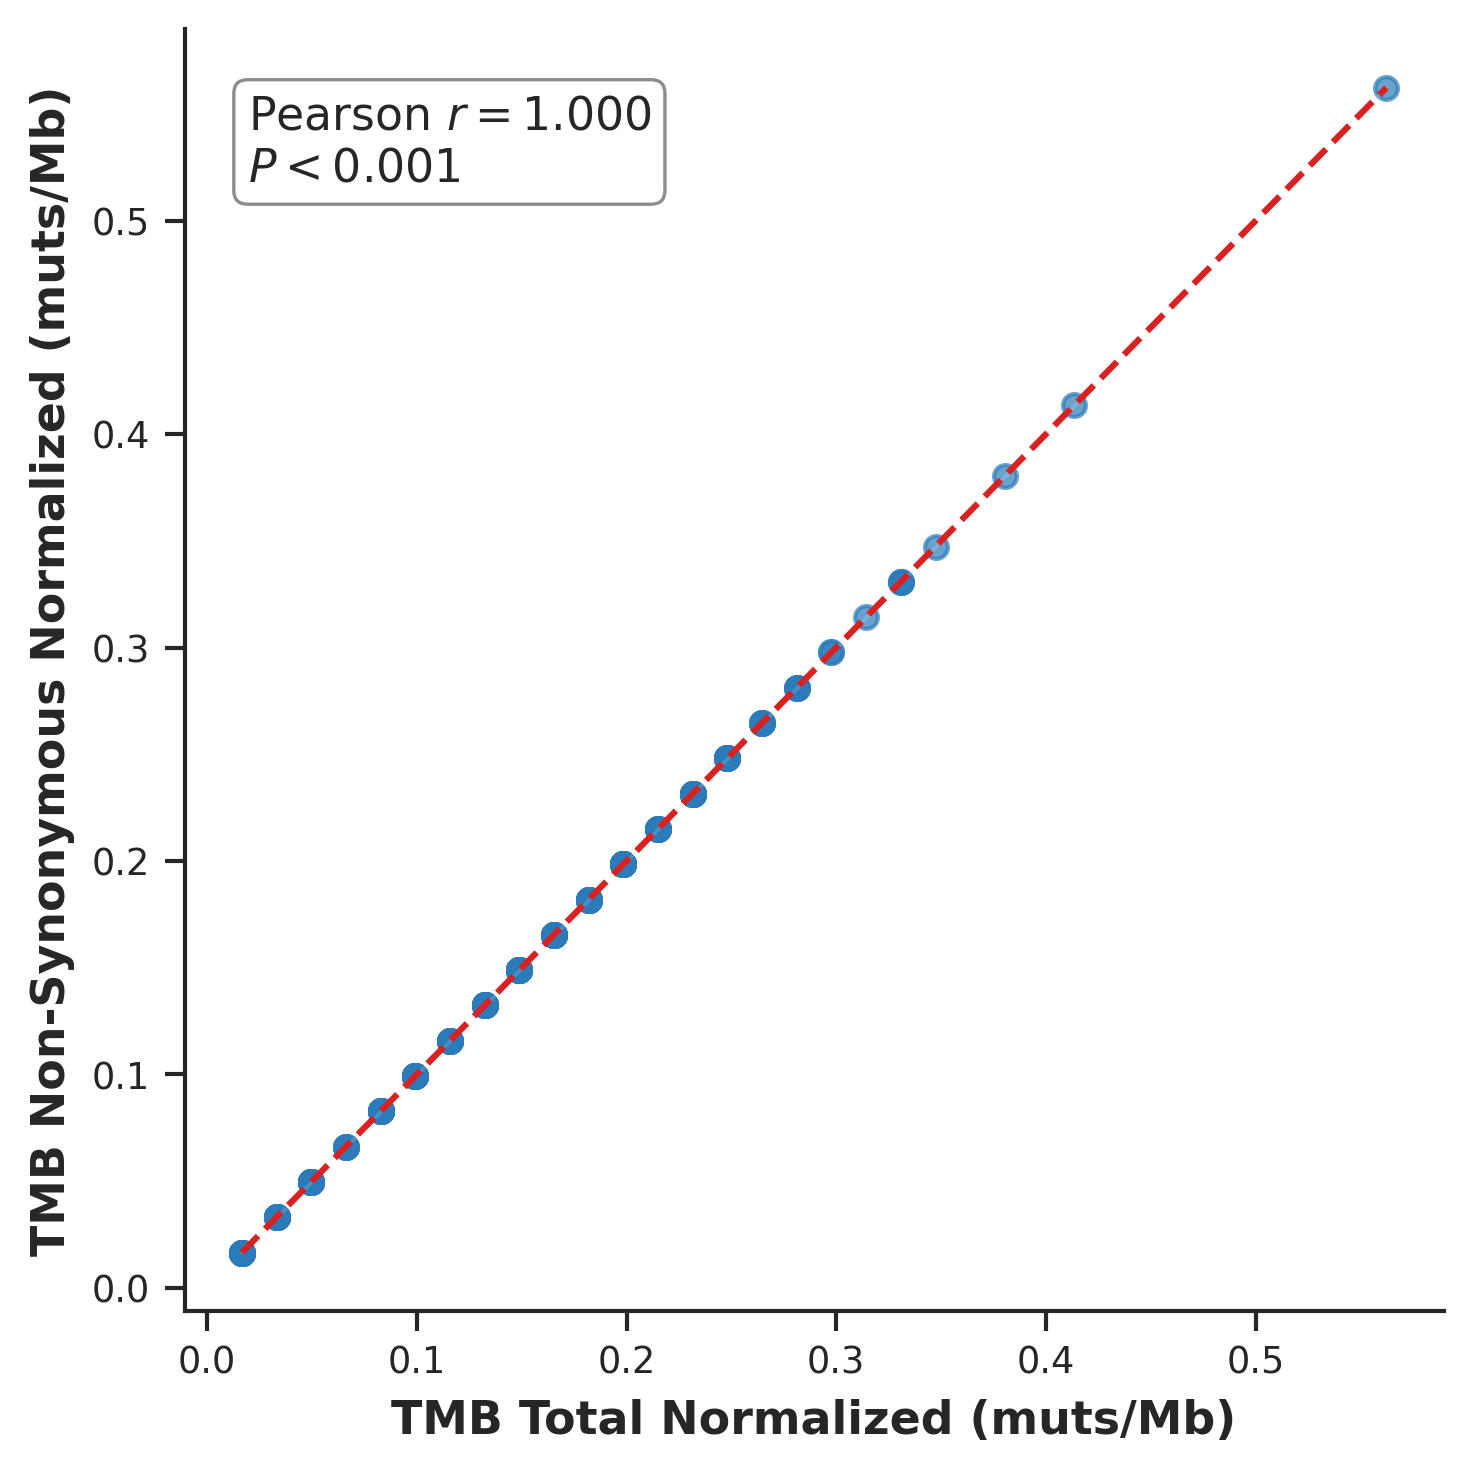

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Cargar los datos
df_analysis = pd.read_csv("results_tmb/TMB_analysis.tsv", sep="\t")

# 2. Configurar el estilo de publicación
sns.set_theme(style="ticks", context="paper")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']

# 3. Crear la figura (5x5 pulgadas es un buen tamaño para una columna)
fig, ax = plt.subplots(figsize=(5, 5))

# 4. Crear el gráfico de dispersión con línea de regresión
sns.regplot(
    data=df_analysis, 
    x='TMB_Total_Normalized', 
    y='TMB_Non_Synonymous_Normalized',
    scatter_kws={'s': 30, 'alpha': 0.7, 'color': '#2b7bba'}, # Puntos azules
    line_kws={'color': '#d92121', 'linewidth': 1.5, 'linestyle': '--'}, # Línea roja punteada
    ax=ax
)

# 5. Calcular estadísticas
r, p = pearsonr(df_analysis['TMB_Total_Normalized'], df_analysis['TMB_Non_Synonymous_Normalized'])
p_str = "< 0.001" if p < 0.001 else f"= {p:.3f}"

# 6. Añadir caja de texto con r y P
texto = f"Pearson $r = {r:.3f}$\n$P {p_str}$"
ax.text(0.05, 0.95, texto, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# 7. Títulos de los ejes
ax.set_xlabel('TMB Total Normalized (muts/Mb)', fontsize=11, fontweight='bold')
ax.set_ylabel('TMB Non-Synonymous Normalized (muts/Mb)', fontsize=11, fontweight='bold')

# 8. Limpiar bordes (Despine)
sns.despine()

# 9. Guardar en formato vectorial para el paper
plt.tight_layout()
plt.savefig('Figura_TMB_Correlation.pdf', format='png', dpi=300)
plt.show()

In [16]:
# 'fig' captura el objeto antes de que se limpie
fig = py_mutation.summary_plot()

# Guardamos directamente desde el objeto capturado
fig.savefig("mutation_summary.png", dpi=300, bbox_inches='tight')

2026-04-30 12:22:02,903 | INFO | pyMut.core | Generating summary plot...
2026-04-30 12:22:07,578 | INFO | pyMut.core | Summary plot generated in 4.68 seconds


Oncoplot generated: 10 genes × 184 samples (4.70s)


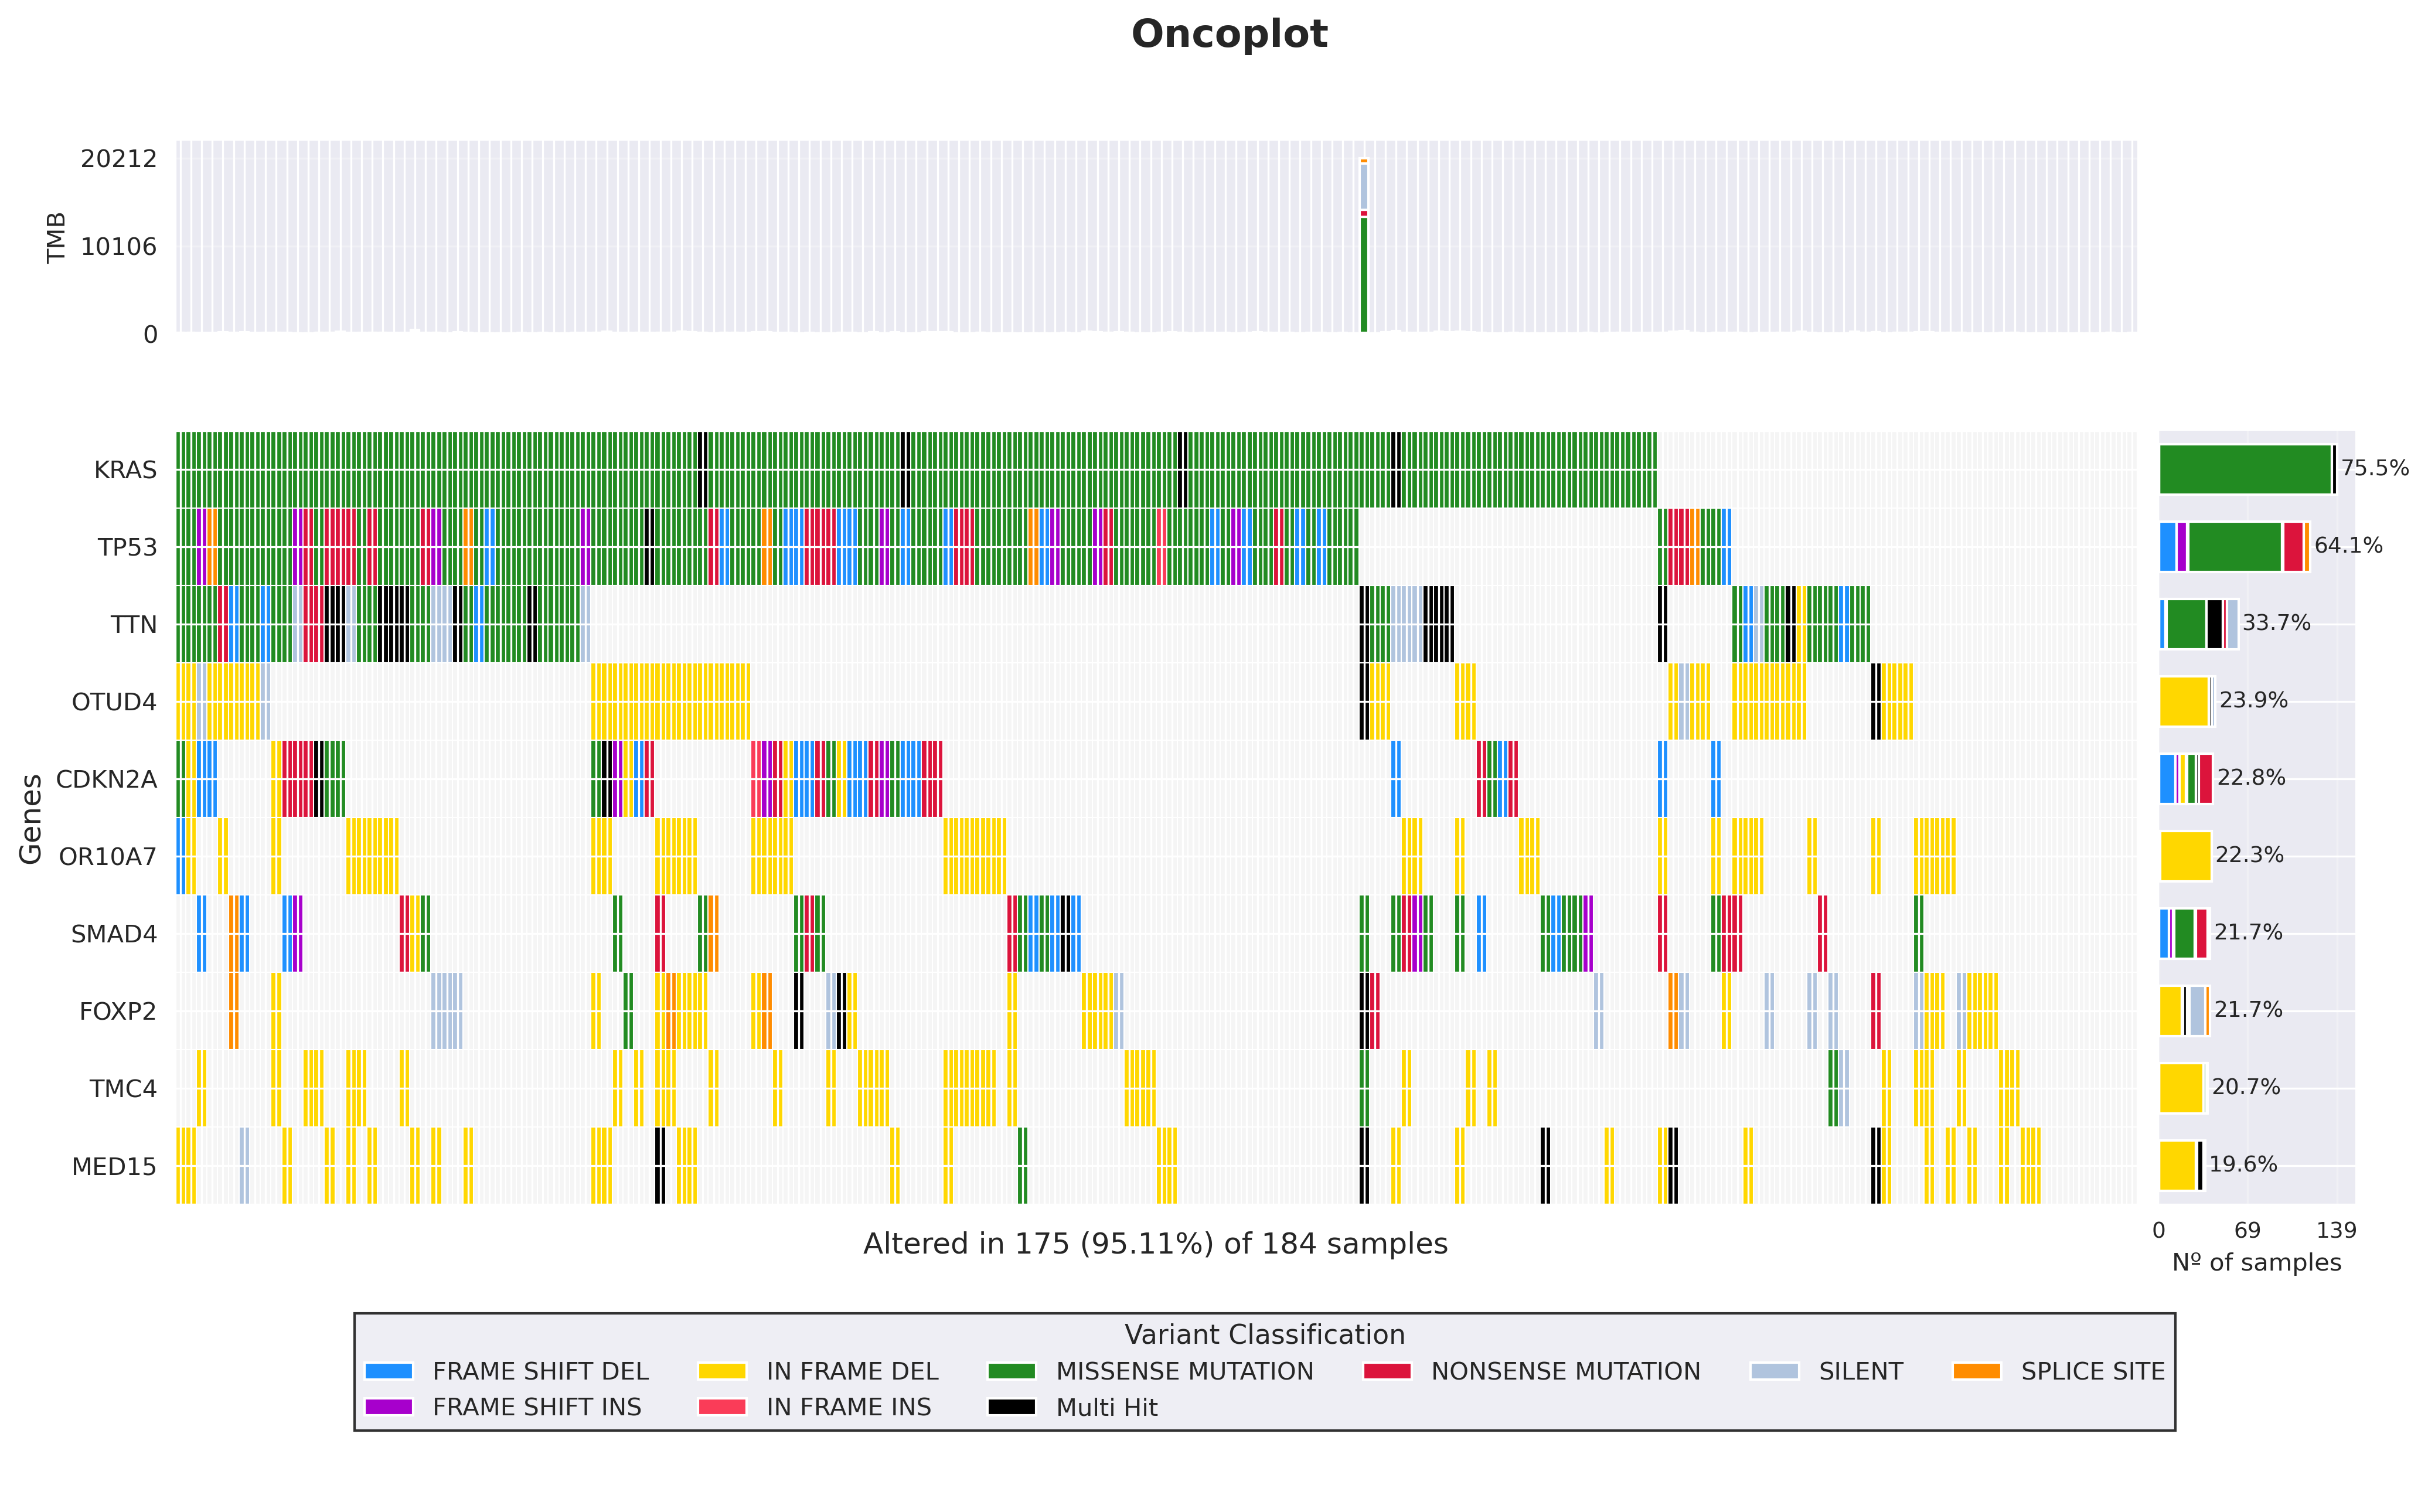

In [8]:
py_mutation.oncoplot()

2026-04-30 12:11:55,485 | INFO | pyMut.visualizations.somatic_interactions | Somatic interactions plot: 28,535 variants, 184 samples, 25 genes analyzed in 0.72s


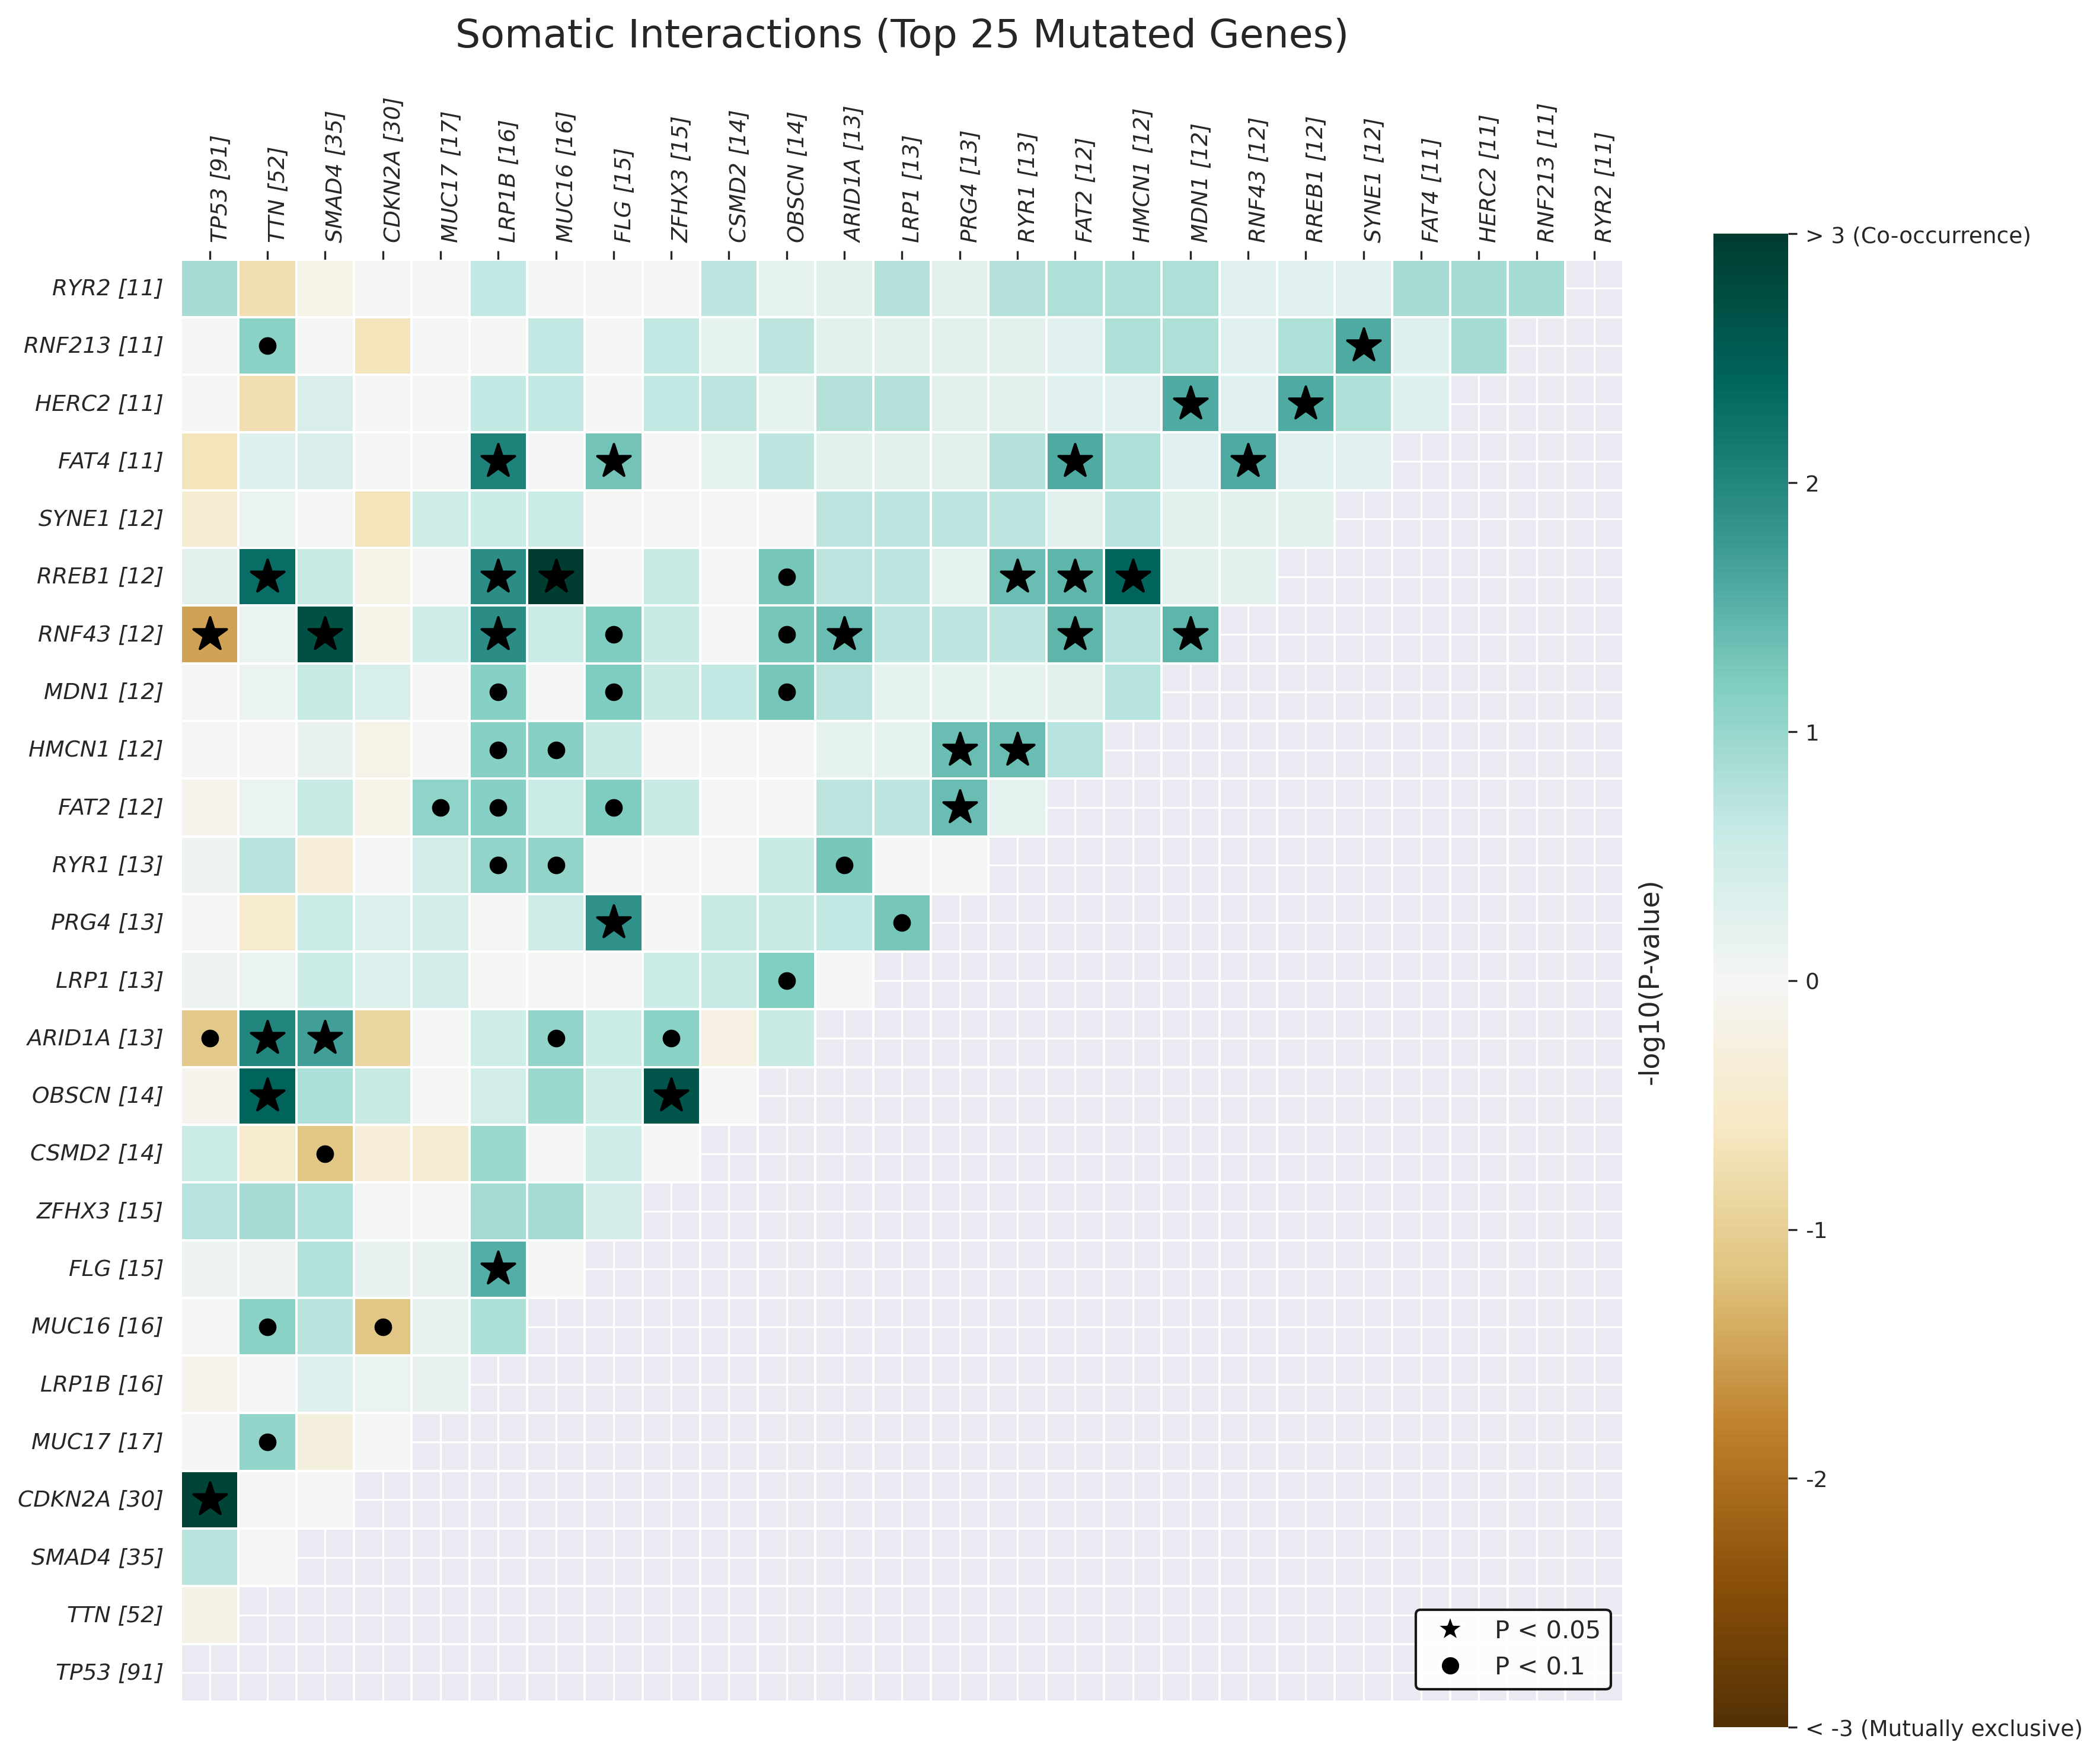

In [9]:
py_mutation.somatic_interactions()

2026-04-30 12:11:56,157 | INFO | pyMut.core | Generating complete mutational signature analysis...
/home/cocdrilo/miniconda3/envs/PyMutTFG/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
2026-04-30 12:12:15,677 | INFO | pyMut.analysis.mutational_signature | NMF signature extraction completed in 0.02 seconds
2026-04-30 12:12:15,680 | INFO | pyMut.visualizations.mutational_signature_analysis | Generating complete mutational signature analysis...
2026-04-30 12:12:15,704 | INFO | pyMut.visualizations.mutational_signature_analysis | Generating signature bar chart...
2026-04-30 12:12:15,909 | INFO | pyMut.visualizations.mutational_signature_analysis | Signature bar chart generated in 0.20s
2026-04-30 12:12:15,920 | INFO | pyMut.visualizations.mutational_signature_analysis | Generating cosine similarity heatmap...
2026-04-30 12:12:16,243 | INFO | pyMut.visualizat

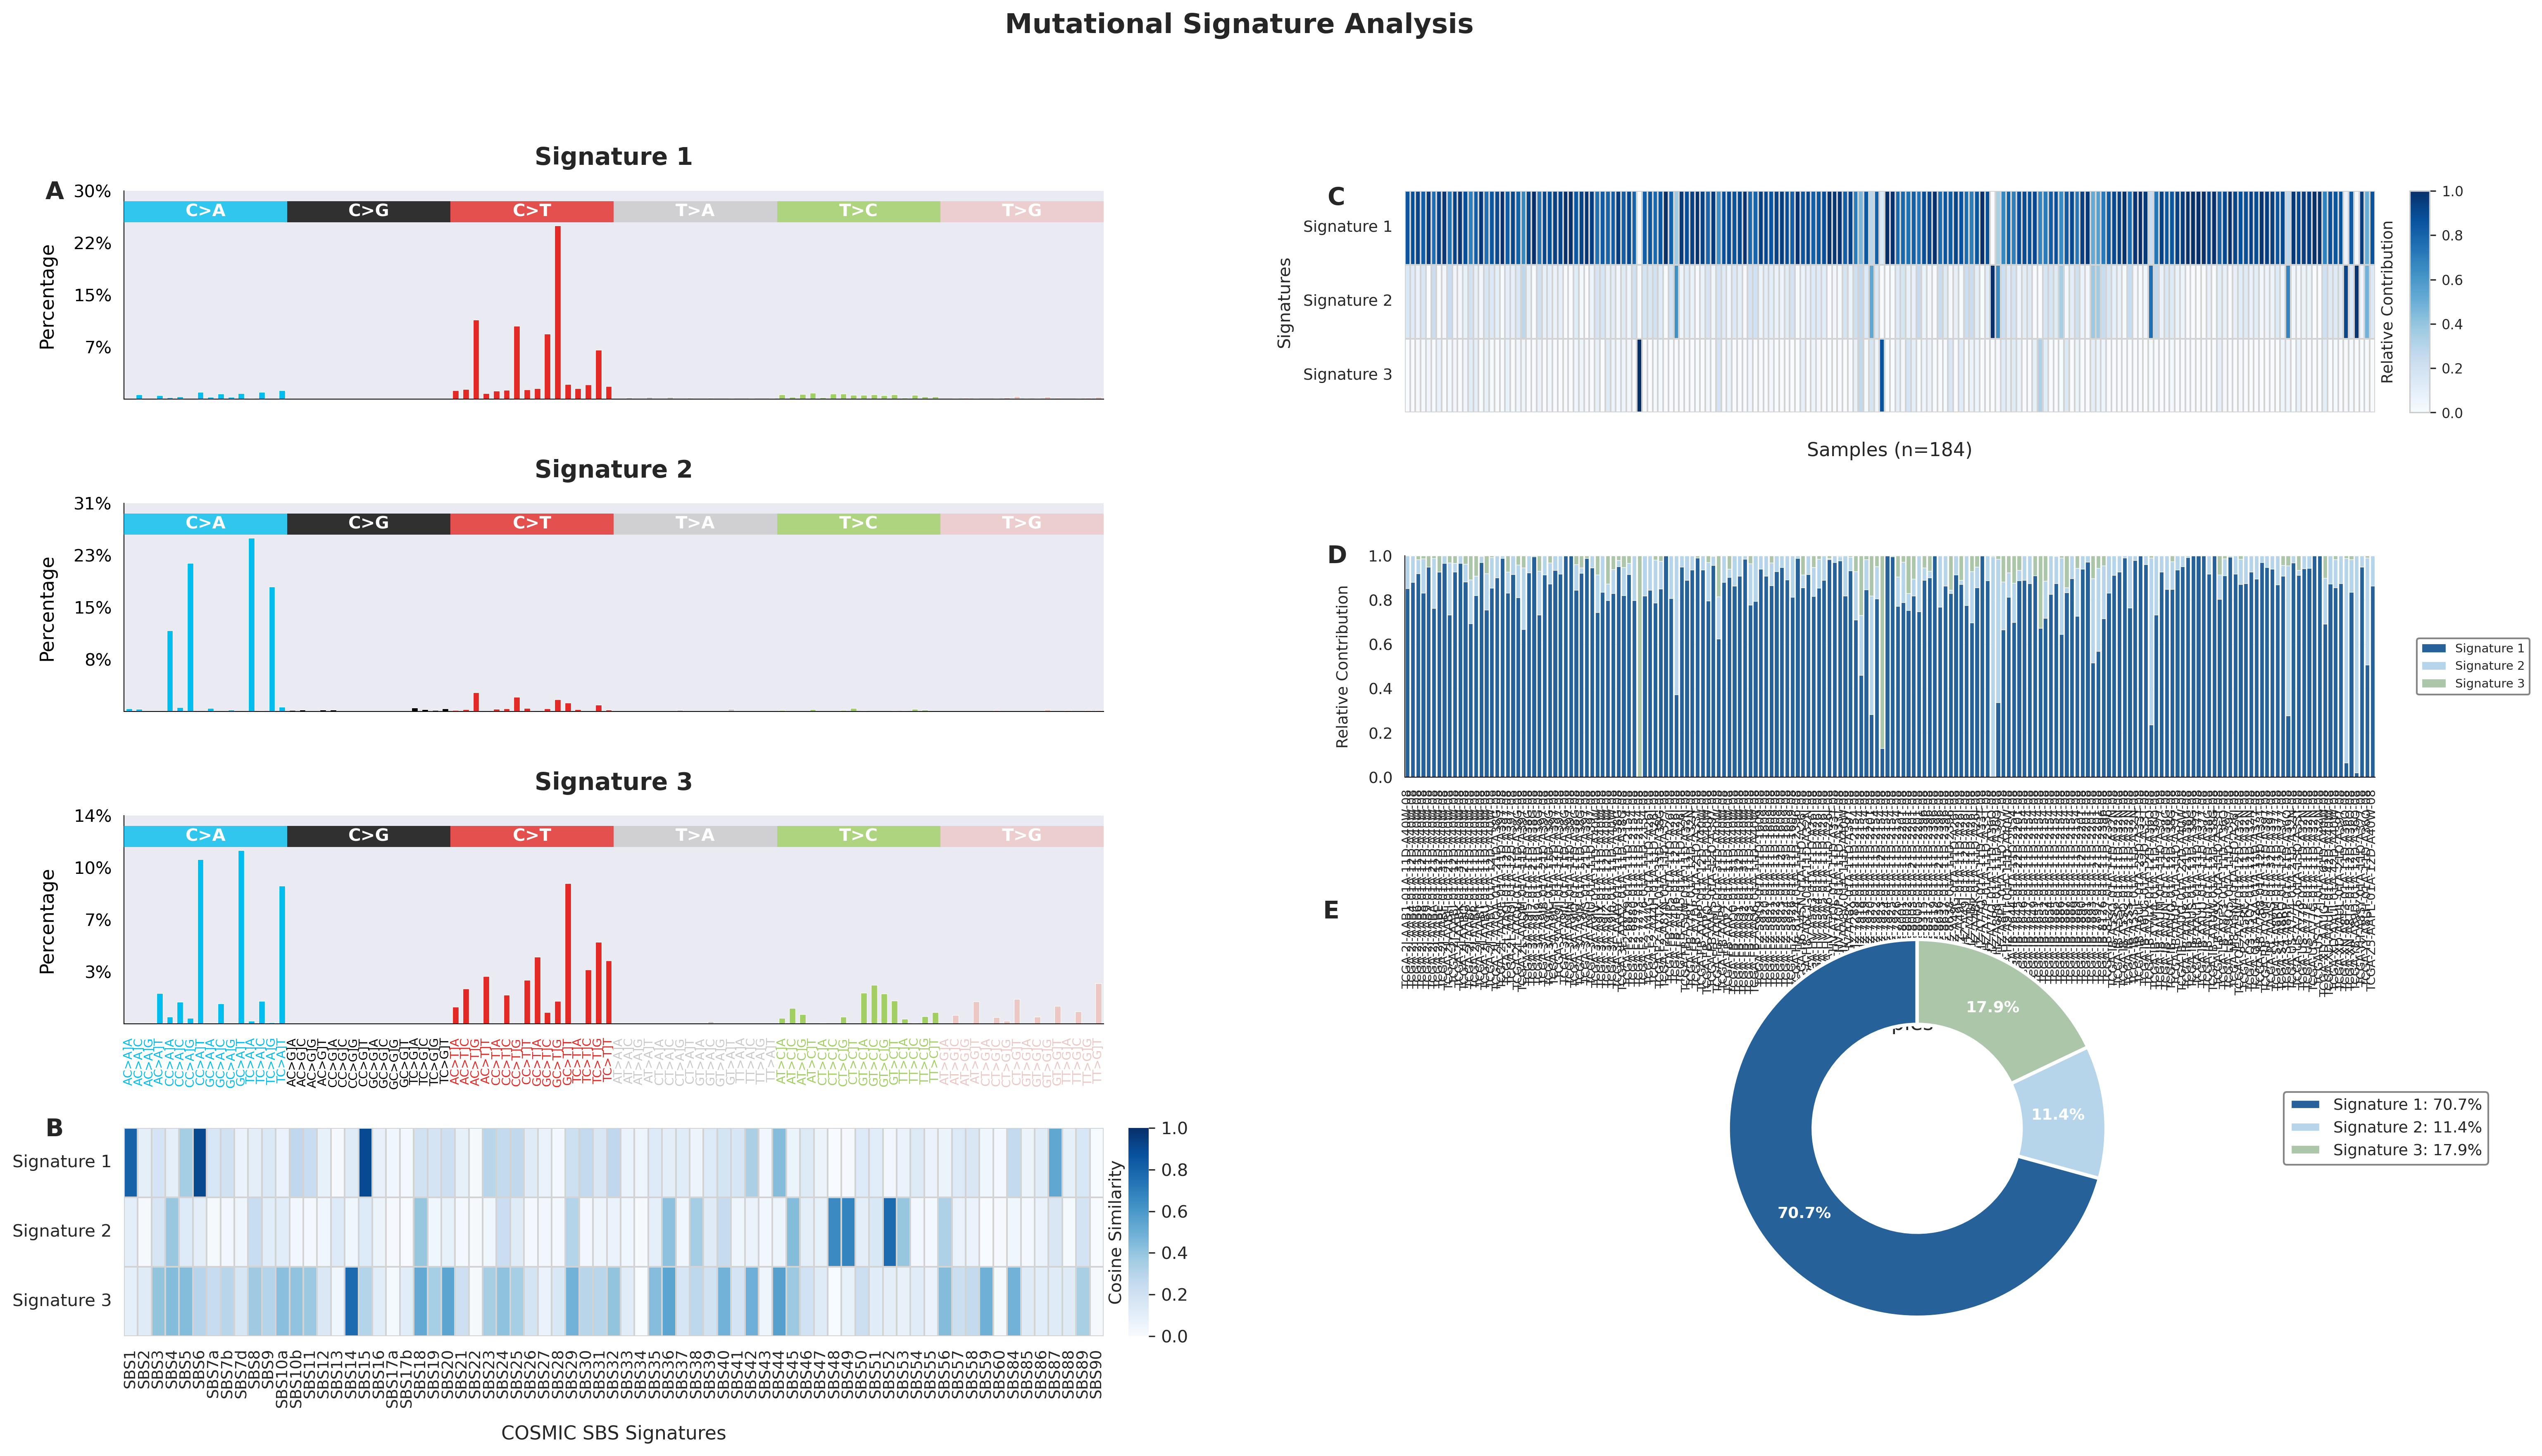

In [10]:
py_mutation.mutational_signature_analysis(
    ref_genome="res/Homo_sapiens.GRCh37.dna.toplevel.fa",
    cosmic_path="res/COSMIC_72.tsv",
)